## NBA Points per Minute Predictor - XGBoost Quantile
**- Owner:** Alex

**- Status:** Exploration only - not a production pipeline yet

**- Last Updated:** 10/3/26

### Question

**How accurately can we predict an NBA player's points per minute in their next game,
and can XGBoost beat last-game points per minute, the season-to-date average, and an EWMA of recent points per minute?**

### Decision Criteria
**- Primary metric:** q50 pinball (points per minute). Lower is better.

**- Secondary metric:** 80% interval (q10–q90) and 90% interval (q05–q95) coverage near their targets

**- Serving threshold:** none yet — exploration only

**- Guardrail:** no quantile crossing; 2025-26 is scored once and never used to tune

### Data Contract
**- Data:** nba_api, rotowire, and basketball reference

**- Unit:** one row per player-game (`game_id`, `player_id`)

**- Features:** `PTS_FEATURES` from the points model. Pregame only. Game N minutes, game N points, and `predicted_minutes_oof` are excluded.

**- Split:** chronological; train through 2024-25, hold out 2025-26


### Setup and Configurations


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

def _repo_root() -> Path:
    starts = []
    nb = globals().get("__vsc_ipynb_file__")
    if nb:
        starts.append(Path(nb).resolve().parent)
    starts.append(Path.cwd().resolve())
    for start in starts:
        for candidate in (start, *start.parents):
            if (candidate / "pyproject.toml").is_file():
                return candidate
    raise RuntimeError("could not find repo root (pyproject.toml)")

ROOT = _repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features.minutes.rolling import prior_ewm, prior_expanding, prior_shift
from src.features.points import add_points_features


In [ ]:
# ── Prop-specific config (capped points per minute) ──────────────────────────

HOLDOUT_SEASON = "2025-26"
ID_COLS = ["game_id", "player_id", "season_year", "player_name", "game_date"]
RATE_CAP = 6.0
TARGET_COL = "pts_per_min"
ROLE_COL = "starting"
SEED = 42

QUANTILES = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

# Rate search already run in pts_nba_model. Pre-holdout pool only.
XGB_PARAMS = dict(
    objective="reg:quantileerror",
    n_estimators=1695,
    max_depth=3,
    learning_rate=0.052852647946832816,
    subsample=0.5916232263322159,
    colsample_bytree=0.6284413523882679,
    reg_alpha=0.022871045941195746,
    reg_lambda=2.0960269065270034,
    min_child_weight=8,
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=50,
)
RATE_TIERS = {
    "<0.30": lambda a: a < 0.30,
    "0.30-0.50": lambda a: (a >= 0.30) & (a < 0.50),
    "0.50-0.70": lambda a: (a >= 0.50) & (a < 0.70),
    "0.70+": lambda a: a >= 0.70,
}

ARTIFACT_STEM = "pts_nba_model"

from models.shared.splits import prepare_splits, tukey_fences
from models.shared.train import (
    evaluate_holdout,
    run_timeseries_cv,
    run_walk_forward,
)
from models.shared.analysis import run_feature_ablation, analyze_correlations
from models.shared.artifacts import save_model_bundle, load_model_bundle, predict_quantiles
from models.shared.metrics import interval_coverage, pinball_50, pinball_loss
from models.shared.oos import capped_rate


### Data


In [3]:
s20 = pd.read_parquet(ROOT / "data/silver/nba/2019-20/regular_season/player_gamelogs.parquet")
s21 = pd.read_parquet(ROOT / "data/silver/nba/2020-21/regular_season/player_gamelogs.parquet")
s22 = pd.read_parquet(ROOT / "data/silver/nba/2021-22/regular_season/player_gamelogs.parquet")
s23 = pd.read_parquet(ROOT / "data/silver/nba/2022-23/regular_season/player_gamelogs.parquet")
s24 = pd.read_parquet(ROOT / "data/silver/nba/2023-24/regular_season/player_gamelogs.parquet")
s25 = pd.read_parquet(ROOT / "data/silver/nba/2024-25/regular_season/player_gamelogs.parquet")
s26 = pd.read_parquet(ROOT / "data/silver/nba/2025-26/regular_season/player_gamelogs.parquet")
df = pd.concat([s20, s21, s22, s23, s24, s25, s26])
df['starting'] = (
    df['start_position'].astype('string').str.strip().isin(['G', 'F', 'C']).astype(int)
)
df.sample(5)


,season_year,player_id,player_name,nickname,team_id,team_abbreviation,team_name,game_id,game_date,matchup,...,opp_pace,opp_pace_per40,opp_poss,opp_pie,season_type,pos,game_total,team_spread,player_team_spread,starting
10411,2024-25,202691,Klay Thompson,Klay,1610612742,DAL,Dallas Mavericks,0022400712,2025-02-04T00:00:00,DAL @ PHI,...,94.5,78.75,94,0.518,Regular Season,SF,227.5,-4.0,4.0,1
25808,2023-24,1630184,Kira Lewis Jr.,Kira,1610612740,NOP,New Orleans Pelicans,0022300090,2023-10-28T00:00:00,NOP vs. NYK,...,100.5,83.75,100,0.472,Regular Season,PG,223.5,-3.0,-3.0,0
3877,2024-25,1630241,Sam Merrill,Sam,1610612739,CLE,Cleveland Cavaliers,0022401021,2025-03-21T00:00:00,CLE @ PHX,...,96.0,80.00,96,0.544,Regular Season,SG,233.5,8.5,-8.5,0
13694,2021-22,1630528,Josh Christopher,Josh,1610612745,HOU,Houston Rockets,0022100586,2022-01-07T00:00:00,HOU vs. DAL,...,104.5,87.08,104,0.630,Regular Season,SG,215.0,3.0,3.0,0
21881,2024-25,1630162,Anthony Edwards,Anthony,1610612750,MIN,Minnesota Timberwolves,0022400234,2024-11-17T00:00:00,MIN vs. PHX,...,96.0,80.00,96,0.471,Regular Season,SG,218.5,-7.5,-7.5,1


In [102]:
# Data Quality Checks
print(f"Number of rows : {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print(f"Number of Unique Players: {df['player_id'].nunique()}")
print(f"Number of Unique Games: {df['game_id'].nunique()}")
print(f"Total number of duplicates: {df.duplicated(subset=['game_id', 'player_id']).sum()}")
print(f"Missing points: {df['pts'].isna().sum()}")
print(f"Missing minutes: {df['minutes'].isna().sum()}")
print(f"Zero-minute rows: {int((df['minutes'] == 0).sum())}")
print(f"Median points: {df['pts'].median()}")
print(f"Mean points: {df['pts'].mean().round(3)}")
played = df.loc[df["minutes"] > 0, "pts"] / df.loc[df["minutes"] > 0, "minutes"]
print(f"Median points per minute (appearances): {played.median():.3f}")
print(f"Mean points per minute (appearances): {played.mean():.3f}")
print(f"Max raw points per minute: {played.max():.3f}")


Number of rows : 176738
Number of columns: 190
Number of Unique Players: 1172
Number of Unique Games: 8289
Total number of duplicates: 0
Missing points: 0
Missing minutes: 0
Zero-minute rows: 13
Median points: 9.0
Mean points: 10.629
Median points per minute (appearances): 0.409
Mean points per minute (appearances): 0.428
Max raw points per minute: 30.000


### Features


In [103]:
# adds features to the dataset
df = add_points_features(df)

In [104]:
# selected features to use in the model
PTS_FEATURES = [
    "pts_per_min_ewm_hl_10",
    "player_fga_share_10",
    "ppm_trim_mean_20",
    "current_team_pts_per_min",
    "usg_wmean_10",
    "season_pts_per_min",
    "starting",
    "fta_per_min_10",
    "ppm_unstable",
    "opp_def_rating_mean_10",
    "team_spread_canonical",
    "min_mean_10",
]
_EXCLUDED_FEATURES = {"minutes", "pts", "predicted_minutes_oof"}
leaked = _EXCLUDED_FEATURES.intersection(PTS_FEATURES)
if leaked:
    raise AssertionError(f"Game-N outcomes leaked into features: {sorted(leaked)}")
missing = [column for column in PTS_FEATURES if column not in df.columns]
if missing:
    raise KeyError(f"Rate features missing from the panel: {missing}")
print(f"Number of features: {len(PTS_FEATURES)}")
print(f"Number of nulls: {df[PTS_FEATURES].isna().sum().sum()}")


Number of features: 12
Number of nulls: 45820


### Train/validation/test design
**- Train:** 2019-10-22 → 2025-04-13 (2019-20, 2020-21, 2021-22, 2022-23, 2023-24, 2024-25). Each fold fits on its past dates. The 2025-26 fit uses the first 90% of this pool.

**- Validation:** Inside the train pool only. Optuna picks hyperparameters on a 3-fold TimeSeriesSplit by q50 pinball. Walk-forward then scores 4 non-overlapping blocks, each the next 10% of game dates after a 50% training window, stepping forward 10%. Those windows end 2024-11-25, 2024-12-31, 2025-02-01, and 2025-03-10. The first half of train dates, and dates after 2025-03-10, are never scored.

**- Test:** 2025-10-21 → 2026-04-12 (2025-26). Scored once, after features and hyperparameters are locked on the validation folds.

**- Split type:** Chronological. Walk-forward keeps every row from a game_date on one side. TimeSeriesSplit cuts by row index, so one slate can straddle a fold.

**- Embargo:** None. The next game date after the last training date is validation. The gap from 2025-04-13 to 2025-10-21 is the offseason, not a purge.

**- Important:** 2025-26 is not used to choose features, hyperparameters, or early-stopping rounds. Walk-forward still early-stops on the rows it scores. The holdout fit early-stops on the last 10% of the train pool and never puts 2025-26 in eval_set.


In [105]:
df = df.loc[df["minutes"] > 0].copy()
df = df.sort_values(
    ["game_date", "game_id", "player_id"], kind="mergesort"
).reset_index(drop=True)
df[TARGET_COL] = capped_rate(df["pts"], df["minutes"], cap=RATE_CAP)
# Naive baselines for the points-per-minute label. Not model features.
# EWMA is the pregame rate: ewm(points) / ewm(minutes), half-life 10.
df["pts_per_min_lag_1"] = prior_shift(df, TARGET_COL, ["player_id"])
df["season_pts_per_min_mean"] = prior_expanding(
    df, TARGET_COL, ["player_id", "season_year"], "mean"
)
print(f"After filtering appearances: {len(df):,} rows")
print(df[TARGET_COL].describe().round(3))

splits = prepare_splits(
    df,
    holdout_season=HOLDOUT_SEASON,
    features=PTS_FEATURES,
    target_col=TARGET_COL,
    id_cols=ID_COLS,
    role_col=ROLE_COL,
    extra_keep=[
        "minutes",
        "pts",
        "pts_per_min_lag_1",
        "season_pts_per_min_mean",
        "pts_per_min_ewm_hl_10",
    ],
)
ppm_df = splits["ppm_df"]
ppm_holdout = splits["ppm_holdout"]
X = splits["X"]
y = splits["y"]
print(f"Train pool (excl. {HOLDOUT_SEASON}) : {len(ppm_df):,} rows")
print(f"Holdout   ({HOLDOUT_SEASON})        : {len(ppm_holdout):,} rows")
print(
    f"Date range (train)   : {ppm_df['game_date'].min().date()} → "
    f"{ppm_df['game_date'].max().date()}"
)
print(
    f"Date range (holdout) : {ppm_holdout['game_date'].min().date()} → "
    f"{ppm_holdout['game_date'].max().date()}"
)

# Fences come from the train pool only. 2025-26 does not move the cutoff.
# Rates on the fence stay. The holdout still contains every appearance.
fence_low, fence_high = tukey_fences(ppm_df[TARGET_COL])
keep = ppm_df[TARGET_COL].between(fence_low, fence_high)
n_train = len(ppm_df)
n_dropped = int((~keep).sum())
ppm_df = ppm_df.loc[keep].reset_index(drop=True)
X = ppm_df[splits["features"]].copy()
y = ppm_df[TARGET_COL]
print(
    f"Train Tukey fence [{fence_low:.2f}, {fence_high:.2f}]: "
    f"dropped {n_dropped:,} of {n_train:,} extreme rates "
    f"({n_dropped / n_train:.1%})"
)
print(f"Train pool after outlier drop: {len(ppm_df):,} rows")
print(f"Holdout still includes every appearance: {len(ppm_holdout):,} rows")


After filtering appearances: 176,710 rows
count    176710.000
mean          0.428
std           0.295
min           0.000
25%           0.229
50%           0.409
75%           0.597
max           6.000
Name: pts_per_min, dtype: float64
Train pool (excl. 2025-26) : 150,062 rows
Holdout   (2025-26)        : 26,648 rows
Date range (train)   : 2019-10-22 → 2025-04-13
Date range (holdout) : 2025-10-21 → 2026-04-12
Train pool (excl. 2025-26) : 150,062 rows
Holdout   (2025-26)        : 26,648 rows
Date range (train)   : 2019-10-22 → 2025-04-13
Date range (holdout) : 2025-10-21 → 2026-04-12


### EDA


Appearance rows: 176,710
Features with a null: 11 / 12
Rows with any null feature: 25,174 (14.2%)


,n_missing,pct_missing
ppm_unstable,15416,8.72
ppm_trim_mean_20,13443,7.61
team_spread_canonical,4197,2.38
season_pts_per_min,3936,2.23
current_team_pts_per_min,2624,1.48
pts_per_min_ewm_hl_10,1172,0.66
player_fga_share_10,1172,0.66
usg_wmean_10,1172,0.66
fta_per_min_10,1172,0.66
min_mean_10,1172,0.66


,ppm_unstable,ppm_trim_mean_20,team_spread_canonical,season_pts_per_min,current_team_pts_per_min,pts_per_min_ewm_hl_10,player_fga_share_10,usg_wmean_10,fta_per_min_10,min_mean_10,opp_def_rating_mean_10
season_year,,,,,,,,,,,
2019-20,8.1,15.8,7.7,2.4,2.6,2.4,2.4,2.4,2.4,2.4,1.4
2020-21,9.5,7.5,0.0,2.3,1.4,0.5,0.5,0.5,0.5,0.5,0.0
2021-22,8.6,6.3,2.3,2.3,1.6,0.5,0.5,0.5,0.5,0.5,0.0
2022-23,7.9,4.7,0.7,2.1,1.1,0.3,0.3,0.3,0.3,0.3,0.0
2023-24,9.3,6.3,3.9,2.2,1.3,0.4,0.4,0.4,0.4,0.4,0.0
2024-25,9.3,7.5,0.2,2.2,1.2,0.4,0.4,0.4,0.4,0.4,0.0
2025-26,8.4,6.2,2.3,2.2,1.3,0.4,0.4,0.4,0.4,0.4,0.0


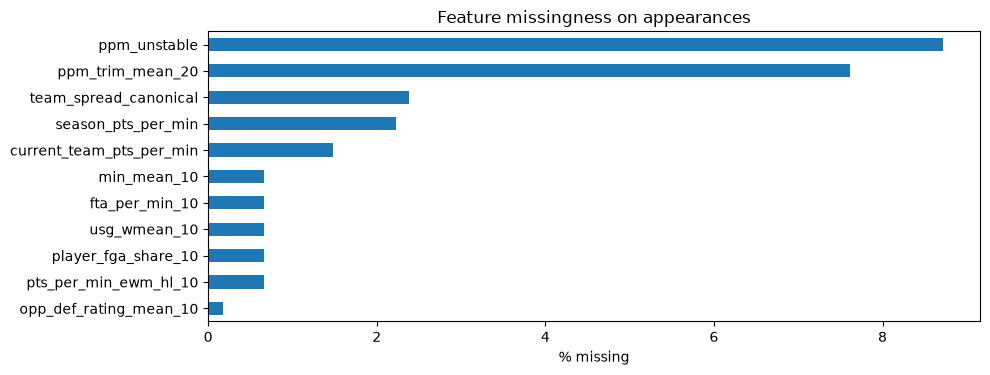

In [106]:
# Feature missingness

miss = pd.DataFrame({
    "n_missing": df[PTS_FEATURES].isna().sum(),
    "pct_missing": (df[PTS_FEATURES].isna().mean() * 100).round(2),
}).sort_values(["pct_missing", "n_missing"], ascending=False)

n_any = int(df[PTS_FEATURES].isna().any(axis=1).sum())
print(f"Appearance rows: {len(df):,}")
print(f"Features with a null: {int((miss['n_missing'] > 0).sum())} / {len(PTS_FEATURES)}")
print(f"Rows with any null feature: {n_any:,} ({n_any / len(df):.1%})")

sparse = miss.index[miss["n_missing"] > 0].tolist()
display(miss)
if sparse:
    season_miss_pct = (
        df[sparse]
        .isna()
        .groupby(df["season_year"], sort=True)
        .mean()
        .mul(100)
        .round(1)
    )
    display(season_miss_pct)
    fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(sparse))))
    miss.loc[sparse, "pct_missing"].sort_values().plot.barh(ax=ax, color="C0")
    ax.set_xlabel("% missing")
    ax.set_title("Feature missingness on appearances")
    fig.tight_layout()
    plt.show()
else:
    print("Every selected feature is complete on this frame.")


n=176,710  min=0.00  p50=0.41  max=6.00
Tukey fence [-0.32, 1.15]  outside=2,397 (1.4%)
Rows at the 6 points-per-minute cap: 9


,season_year,game_date,player_name,pts_per_min,starting
8747,2019-20,2019-12-18,Ryan Broekhoff,6.0,0
17702,2019-20,2020-02-22,Jalen Brunson,6.0,1
75613,2022-23,2022-11-12,Dyson Daniels,6.0,0
79523,2022-23,2022-12-08,Keon Johnson,6.0,0
97266,2022-23,2023-04-09,Wendell Moore Jr.,6.0,0
100446,2023-24,2023-11-12,Brandin Podziemski,6.0,0
113557,2023-24,2024-02-06,Jordan Goodwin,6.0,0
114268,2023-24,2024-02-11,Orlando Robinson,6.0,0


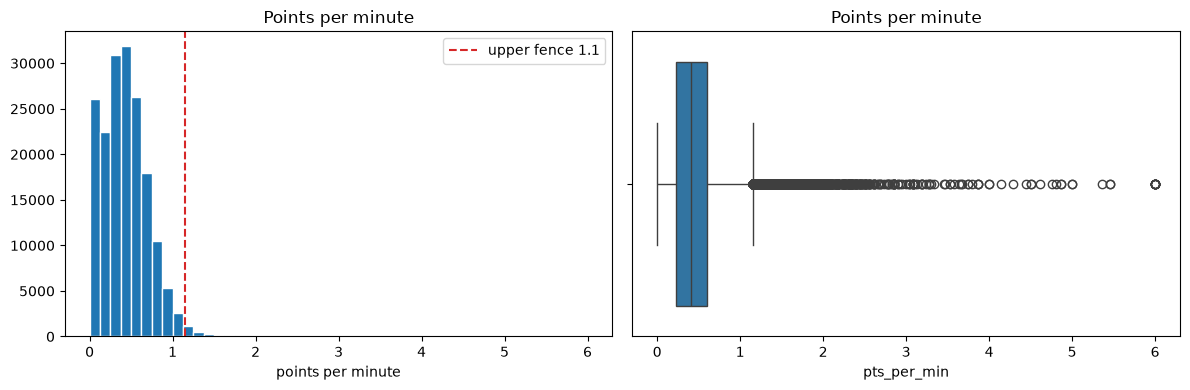

Binary inputs are omitted. A point is outside when it is past 1.5 IQR from the quartiles.


,feature,n,pct_outside,fence_low,fence_high,min,p50,max
0,current_team_pts_per_min,174086,3.21,0.08,0.77,0.00,0.42,3.30
1,season_pts_per_min,172774,3.01,0.04,0.81,0.00,0.41,3.30
2,fta_per_min_10,175538,2.85,-0.07,0.23,0.00,0.07,1.43
3,pts_per_min_ewm_hl_10,175538,2.66,0.05,0.80,0.00,0.42,3.30
4,ppm_trim_mean_20,163267,1.85,0.04,0.81,0.00,0.41,1.11
5,usg_wmean_10,175538,1.41,0.03,0.33,0.00,0.18,1.00
6,opp_def_rating_mean_10,176390,0.82,99.36,126.53,85.00,112.95,133.00
7,player_fga_share_10,175538,0.77,-0.07,0.25,0.00,0.08,0.33
8,team_spread_canonical,172513,0.04,-23.25,22.75,-25.50,-1.00,25.50
9,min_mean_10,175538,0.00,-5.86,51.81,0.02,23.43,45.00


In [107]:
# Outliers

rate = df[TARGET_COL]
q1, q3 = rate.quantile(0.25), rate.quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_tukey = int(((rate < lo) | (rate > hi)).sum())
n_ot = int((rate >= RATE_CAP).sum())
print(
    f"n={len(rate):,}  min={rate.min():.2f}  "
    f"p50={rate.median():.2f}  max={rate.max():.2f}"
)
print(
    f"Tukey fence [{lo:.2f}, {hi:.2f}]  "
    f"outside={n_tukey:,} ({n_tukey / len(rate):.1%})"
)
print(f"Rows at the {RATE_CAP:g} points-per-minute cap: {n_ot:,}")

top_minutes = (
    df.nlargest(8, TARGET_COL)[
        ["season_year", "game_date", "player_name", TARGET_COL, "starting"]
    ]
    .assign(game_date=lambda frame: pd.to_datetime(frame["game_date"]).dt.date)
)
display(top_minutes)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rate, bins=48, color="C0", edgecolor="white")
axes[0].axvline(hi, color="C3", ls="--", label=f"upper fence {hi:.1f}")
axes[0].set_title("Points per minute")
axes[0].set_xlabel("points per minute")
axes[0].legend()
sns.boxplot(x=rate, ax=axes[1], color="C0")
axes[1].set_title("Points per minute")
fig.tight_layout()
plt.show()

outlier_rows = []
for col in PTS_FEATURES:
    values = df[col].dropna()
    if values.nunique(dropna=True) <= 2:
        continue
    fq1, fq3 = values.quantile([0.25, 0.75])
    spread = float(fq3 - fq1)
    if spread <= 0:
        continue
    fence_lo = float(fq1 - 1.5 * spread)
    fence_hi = float(fq3 + 1.5 * spread)
    outside = (values < fence_lo) | (values > fence_hi)
    outlier_rows.append({
        "feature": col,
        "n": int(values.shape[0]),
        "pct_outside": round(100 * float(outside.mean()), 2),
        "fence_low": round(fence_lo, 2),
        "fence_high": round(fence_hi, 2),
        "min": round(float(values.min()), 2),
        "p50": round(float(values.median()), 2),
        "max": round(float(values.max()), 2),
    })

feature_outliers = (
    pd.DataFrame(outlier_rows)
    .sort_values("pct_outside", ascending=False)
    .reset_index(drop=True)
)
print("Binary inputs are omitted. A point is outside when it is past 1.5 IQR from the quartiles.")
display(feature_outliers)


In [108]:
# Coverage by Season

complete = ~df[PTS_FEATURES].isna().any(axis=1)
coverage = df.groupby("season_year", sort=True).agg(
    rows=("player_id", "size"),
    players=("player_id", "nunique"),
    games=("game_id", "nunique"),
    first_game=("game_date", "min"),
    last_game=("game_date", "max"),
)
coverage["first_game"] = pd.to_datetime(coverage["first_game"]).dt.date
coverage["last_game"] = pd.to_datetime(coverage["last_game"]).dt.date
coverage["pct_rows_complete"] = (
    complete.groupby(df["season_year"], sort=True).mean().mul(100).round(1)
)
coverage["mean_missing_features"] = (
    df[PTS_FEATURES]
    .isna()
    .sum(axis=1)
    .groupby(df["season_year"], sort=True)
    .mean()
    .round(2)
)
print(f"Seasons: {len(coverage)}  rows: {int(coverage['rows'].sum()):,}")
display(coverage)


Seasons: 7  rows: 176,710


,rows,players,games,first_game,last_game,pct_rows_complete,mean_missing_features
season_year,,,,,,,
2019-20,22387,529,1059,2019-10-22,2020-08-14,77.2,0.50
2020-21,23053,540,1080,2020-12-22,2021-05-16,87.3,0.23
2021-22,26035,605,1230,2021-10-19,2022-04-10,86.9,0.24
2022-23,25892,539,1230,2022-10-18,2023-04-09,89.6,0.18
2023-24,26393,572,1230,2023-10-24,2024-04-14,84.3,0.25
2024-25,26302,569,1230,2024-10-22,2025-04-13,87.1,0.22
2025-26,26648,582,1230,2025-10-21,2026-04-12,86.9,0.22


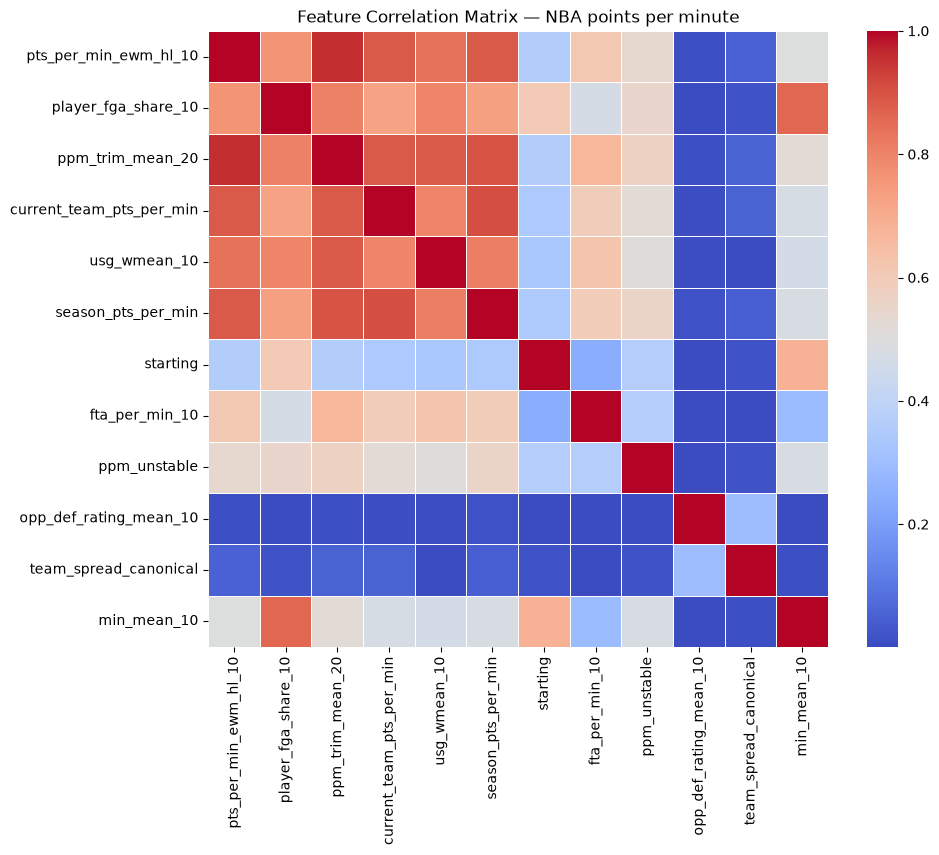

--- High Correlation Report (Threshold > 0.95) ---
ppm_trim_mean_20 <-> pts_per_min_ewm_hl_10: 0.9582


['ppm_trim_mean_20']

In [109]:
correlated_features = analyze_correlations(
    df, PTS_FEATURES, title="Feature Correlation Matrix — NBA points per minute"
)
correlated_features


### Models


In [ ]:
# Hyperparameter tuning
# Leave commented if you don't want to retune the model

# import importlib
# import models.shared.train as train

# importlib.reload(train)
# tune_xgb_quantile = train.tune_xgb_quantile

# result = tune_xgb_quantile(X, y, n_trials=50, n_splits=3)
# XGB_PARAMS = result["best_params"]


In [111]:
# XGBoost using time series cross validation and walk forward validation

tscv_results = run_timeseries_cv(
    X, y, ppm_df,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=RATE_TIERS,
    quantiles=QUANTILES,
)
wf = run_walk_forward(
    X, y, ppm_df,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=RATE_TIERS,
    quantiles=QUANTILES,
    n_folds=5,
)

wf_results = wf["wf_results"]
models_last = wf["models_last"]
preds_last = wf["preds_last"]
X_val_last = wf["X_val_last"]
y_val_last = wf["y_val_last"]
starting_last = wf["starting_last"]
last_fold = wf["last_fold"]


── Phase 1: TimeSeriesSplit (XGBoost) ──────────────────────────

TSCV fold 1
  n=25010
  pinball  | q0.05=0.018  q0.10=0.033  q0.20=0.058  q0.30=0.076  q0.40=0.088  q0.50=0.093  q0.60=0.093  q0.70=0.086  q0.80=0.072  q0.90=0.048  q0.95=0.031
  coverage | 80%=80.1% (target 80%)  90%=90.7% (target 90%)
  Starters   | n=11708 | pinball q50: 0.076 | 80% coverage: 80.9%
  Bench      | n=13302 | pinball q50: 0.109 | 80% coverage: 79.5%
  minute tiers by predicted q50
  <0.30      | n= 5816 | pinball q50: 0.103 | 80% coverage: 83.1%
  0.30-0.50  | n=14196 | pinball q50: 0.093 | 80% coverage: 79.0%
  0.50-0.70  | n= 4006 | pinball q50: 0.082 | 80% coverage: 79.6%
  0.70+      | n=  992 | pinball q50: 0.090 | 80% coverage: 80.1%

TSCV fold 2
  n=25010
  pinball  | q0.05=0.018  q0.10=0.034  q0.20=0.058  q0.30=0.076  q0.40=0.088  q0.50=0.093  q0.60=0.093  q0.70=0.086  q0.80=0.072  q0.90=0.048  q0.95=0.030
  coverage | 80%=80.6% (target 80%)  90%=91.1% (target 90%)
  Starters   | n=11825 | pinbal

In [113]:
def score_predictions(y_true, preds, split: str):
    """Pinball loss per quantile and central interval coverage."""
    y_true = np.asarray(y_true, dtype=float)
    pinball_rows = []
    for key, pred in preds.items():
        alpha = float(str(key).split("_", 1)[1])
        pinball_rows.append({
            "split": split,
            "quantile": alpha,
            "pinball": pinball_loss(y_true, pred, alpha),
        })
    coverage_rows = []
    for low, high, nominal in ((0.10, 0.90, 0.80), (0.05, 0.95, 0.90)):
        low_key, high_key = f"q_{low:.2f}", f"q_{high:.2f}"
        if low_key not in preds or high_key not in preds:
            continue
        coverage_rows.append({
            "split": split,
            "interval": f"{nominal:.0%}",
            "coverage": interval_coverage(y_true, preds[low_key], preds[high_key]),
            "target": nominal,
        })
    return pd.DataFrame(pinball_rows), pd.DataFrame(coverage_rows)


wf_pinball, wf_coverage = score_predictions(
    y_val_last, preds_last, last_fold["fold"]
)
display(wf_pinball.round(4))
display(wf_coverage.round(4))


,split,quantile,pinball
0,WF fold 5 (2025-01-02 → 2025-04-11),0.05,0.0186
1,WF fold 5 (2025-01-02 → 2025-04-11),0.10,0.0340
2,WF fold 5 (2025-01-02 → 2025-04-11),0.20,0.0590
3,WF fold 5 (2025-01-02 → 2025-04-11),0.30,0.0773
4,WF fold 5 (2025-01-02 → 2025-04-11),0.40,0.0895
5,WF fold 5 (2025-01-02 → 2025-04-11),0.50,0.0957
6,WF fold 5 (2025-01-02 → 2025-04-11),0.60,0.0956
7,WF fold 5 (2025-01-02 → 2025-04-11),0.70,0.0889
8,WF fold 5 (2025-01-02 → 2025-04-11),0.80,0.0748
9,WF fold 5 (2025-01-02 → 2025-04-11),0.90,0.0509


,split,interval,coverage,target
0,WF fold 5 (2025-01-02 → 2025-04-11),80%,0.8047,0.8
1,WF fold 5 (2025-01-02 → 2025-04-11),90%,0.9074,0.9


In [114]:
# Test model on holdout set

holdout = evaluate_holdout(
    ppm_df,
    ppm_holdout,
    features=PTS_FEATURES,
    target_col=TARGET_COL,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers=RATE_TIERS,
    wf_results=wf_results,
    quantiles=QUANTILES,
    fold_label=f"{HOLDOUT_SEASON} Blind Holdout",
)
models_ho = holdout["models_ho"]
preds_ho = holdout["preds_ho"]
ho_metrics = holdout["ho_metrics"]
X_ho = holdout["X_ho"]
y_ho = holdout["y_ho"]

ho_pinball, ho_coverage = score_predictions(
    y_ho, preds_ho, f"{HOLDOUT_SEASON} holdout"
)
display(ho_pinball.round(4))
display(ho_coverage.round(4))


── 2025-26 Blind Holdout ─────────────────────────────────────────────────
  Train pool: 90% rows for fit, remainder for early-stopping only; predict holdout (never in eval_set).

2025-26 Blind Holdout
  n=26648
  pinball  | q0.05=0.019  q0.10=0.035  q0.20=0.060  q0.30=0.078  q0.40=0.090  q0.50=0.095  q0.60=0.095  q0.70=0.088  q0.80=0.073  q0.90=0.049  q0.95=0.031
  coverage | 80%=80.2% (target 80%)  90%=90.5% (target 90%)
  Starters   | n=12300 | pinball q50: 0.079 | 80% coverage: 78.8%
  Bench      | n=14348 | pinball q50: 0.109 | 80% coverage: 81.5%
  minute tiers by predicted q50
  <0.30      | n= 6103 | pinball q50: 0.108 | 80% coverage: 85.3%
  0.30-0.50  | n=14172 | pinball q50: 0.094 | 80% coverage: 78.7%
  0.50-0.70  | n= 5144 | pinball q50: 0.086 | 80% coverage: 79.1%
  0.70+      | n= 1229 | pinball q50: 0.091 | 80% coverage: 77.8%

───────────────────────────────────────────────────────
  Walk-forward pinball q50 (mean) : 0.095
  Holdout pinball q50             : 0.095
  Pi

,split,quantile,pinball
0,2025-26 holdout,0.05,0.0189
1,2025-26 holdout,0.10,0.0345
2,2025-26 holdout,0.20,0.0597
3,2025-26 holdout,0.30,0.0779
4,2025-26 holdout,0.40,0.0897
5,2025-26 holdout,0.50,0.0952
6,2025-26 holdout,0.60,0.0946
7,2025-26 holdout,0.70,0.0875
8,2025-26 holdout,0.80,0.0735
9,2025-26 holdout,0.90,0.0495


,split,interval,coverage,target
0,2025-26 holdout,80%,0.8024,0.8
1,2025-26 holdout,90%,0.9054,0.9


In [116]:
# empirical quantile calibration

y_true = np.asarray(y_ho, dtype=float)
calibration_rows = []
for key, pred in preds_ho.items():
    alpha = float(str(key).split("_", 1)[1])
    pred = np.asarray(pred, dtype=float)
    empirical = float(np.mean(y_true <= pred))
    calibration_rows.append({
        "quantile": alpha,
        "target": alpha,
        "empirical": empirical,
        "delta": empirical - alpha,
    })
calibration = (
    pd.DataFrame(calibration_rows)
    .sort_values("quantile")
    .reset_index(drop=True)
)

print(f"{HOLDOUT_SEASON} holdout — empirical quantile calibration")
display(calibration.round(4))


2025-26 holdout — empirical quantile calibration


,quantile,target,empirical,delta
0,0.05,0.05,0.0384,-0.0116
1,0.10,0.10,0.0893,-0.0107
2,0.20,0.20,0.1989,-0.0011
3,0.30,0.30,0.2959,-0.0041
4,0.40,0.40,0.3923,-0.0077
5,0.50,0.50,0.4924,-0.0076
6,0.60,0.60,0.5946,-0.0054
7,0.70,0.70,0.6949,-0.0051
8,0.80,0.80,0.7942,-0.0058
9,0.90,0.90,0.8917,-0.0083


In [117]:
quantile_keys = sorted(
    preds_ho,
    key=lambda key: float(str(key).split("_", 1)[1]),
)
grid = np.column_stack([
    np.asarray(preds_ho[key], dtype=float) for key in quantile_keys
])
crossed = np.any(np.diff(grid, axis=1) < 0, axis=1)
n_rows = int(len(crossed))
n_crossed = int(crossed.sum())
print(
    f"{HOLDOUT_SEASON} holdout quantile crossing: "
    f"{n_crossed:,} / {n_rows:,} rows ({n_crossed / n_rows:.1%})"
)

pair_rows = []
for left, right in zip(quantile_keys, quantile_keys[1:]):
    pair_rate = float(np.mean(
        np.asarray(preds_ho[left], dtype=float)
        > np.asarray(preds_ho[right], dtype=float)
    ))
    pair_rows.append({
        "lower": left,
        "upper": right,
        "crossing_rate": pair_rate,
    })
crossing_pairs = pd.DataFrame(pair_rows)
display(crossing_pairs.round(4))


2025-26 holdout quantile crossing: 801 / 26,648 rows (3.0%)


,lower,upper,crossing_rate
0,q_0.05,q_0.10,0.0005
1,q_0.10,q_0.20,0.0161
2,q_0.20,q_0.30,0.0119
3,q_0.30,q_0.40,0.0050
4,q_0.40,q_0.50,0.0008
5,q_0.50,q_0.60,0.0001
6,q_0.60,q_0.70,0.0001
7,q_0.70,q_0.80,0.0000
8,q_0.80,q_0.90,0.0000
9,q_0.90,q_0.95,0.0000


In [118]:
predicted = np.asarray(preds_ho["q_0.50"], dtype=float)
y_true = np.asarray(y_ho, dtype=float)
low_80 = np.asarray(preds_ho["q_0.10"], dtype=float)
high_80 = np.asarray(preds_ho["q_0.90"], dtype=float)
low_90 = np.asarray(preds_ho["q_0.05"], dtype=float)
high_90 = np.asarray(preds_ho["q_0.95"], dtype=float)
width_80 = high_80 - low_80
width_90 = high_90 - low_90

tier_rows = []
for name, fn in RATE_TIERS.items():
    mask = np.asarray(fn(predicted), dtype=bool)
    n = int(mask.sum())
    if n == 0:
        continue
    tier_rows.append({
        "tier": name,
        "n": n,
        "share": n / len(predicted),
        "pinball_q50": pinball_loss(y_true[mask], predicted[mask], 0.50),
        "empirical_q50": float(np.mean(y_true[mask] <= predicted[mask])),
        "coverage_80": interval_coverage(y_true[mask], low_80[mask], high_80[mask]),
        "coverage_90": interval_coverage(y_true[mask], low_90[mask], high_90[mask]),
        "mean_width_80": float(np.mean(width_80[mask])),
        "mean_width_90": float(np.mean(width_90[mask])),
    })
tier_report = pd.DataFrame(tier_rows)
print(f"{HOLDOUT_SEASON} holdout — rate tiers by predicted q50")
display(tier_report.round(4))


2025-26 holdout — rate tiers by predicted q50


,tier,n,share,pinball_q50,empirical_q50,coverage_80,coverage_90,mean_width_80,mean_width_90
0,<0.30,6103,0.2290,0.1077,0.4958,0.8527,0.9381,0.6385,0.8124
1,0.30-0.50,14172,0.5318,0.0936,0.4905,0.7870,0.8987,0.5848,0.7406
2,0.50-0.70,5144,0.1930,0.0862,0.4930,0.7910,0.8878,0.5458,0.7036
3,0.70+,1229,0.0461,0.0906,0.4939,0.7779,0.8926,0.5610,0.7349


In [ ]:
# Holdout RMSE, CRPS, and tail calibration.
# CRPS is twice the mean pinball across the trained knots.
# Lower tail: share of outcomes at or below the knot.
# Upper tail: share of outcomes above the knot.

from models.shared.minutes_sampler import row_crps

TAIL_KNOTS = (
    ("lower", 0.05),
    ("lower", 0.10),
    ("upper", 0.90),
    ("upper", 0.95),
)


def holdout_point_distribution(name, y, preds):
    y = np.asarray(y, dtype=float)
    levels = sorted(float(str(key).split("_", 1)[1]) for key in preds)
    grid = np.column_stack(
        [np.asarray(preds[f"q_{level:.2f}"], dtype=float) for level in levels]
    )
    q50 = np.asarray(preds["q_0.50"], dtype=float)
    return {
        "model": name,
        "rmse": float(np.sqrt(mean_squared_error(y, q50))),
        "crps": float(np.mean(row_crps(y, grid, np.asarray(levels)))),
    }


def tail_calibration_rows(name, y, preds):
    y = np.asarray(y, dtype=float)
    rows = []
    for side, level in TAIL_KNOTS:
        knot = np.asarray(preds[f"q_{level:.2f}"], dtype=float)
        if side == "lower":
            nominal = level
            empirical = float(np.mean(y <= knot))
        else:
            nominal = 1.0 - level
            empirical = float(np.mean(y > knot))
        rows.append({
            "model": name,
            "side": side,
            "quantile": level,
            "nominal": nominal,
            "empirical": empirical,
            "delta": empirical - nominal,
        })
    return rows


holdout_models = (
    ("XGBoost", y_ho, preds_ho),
)
score_table = pd.DataFrame(
    [holdout_point_distribution(name, y, preds) for name, y, preds in holdout_models]
)
tail_calibration = pd.DataFrame(
    [
        row
        for name, y, preds in holdout_models
        for row in tail_calibration_rows(name, y, preds)
    ]
)

print(
    f"{HOLDOUT_SEASON} holdout — q50 RMSE and 11-knot CRPS\n"
    "  CRPS is twice the mean pinball across the trained knots"
)
display(score_table.round(4))
print(
    f"{HOLDOUT_SEASON} holdout — tail calibration\n"
    "  delta is empirical minus nominal. "
    "A positive delta means more outcomes landed in that tail than the quantile claims"
)
display(tail_calibration.round(4))


In [ ]:
def interval_sharpness(y_true, preds):
    y_true = np.asarray(y_true, dtype=float)
    rows = []
    for low, high, nominal in ((0.10, 0.90, 0.80), (0.05, 0.95, 0.90)):
        low_key, high_key = f"q_{low:.2f}", f"q_{high:.2f}"
        width = (
            np.asarray(preds[high_key], dtype=float)
            - np.asarray(preds[low_key], dtype=float)
        )
        rows.append({
            "interval": f"{nominal:.0%}",
            "coverage": interval_coverage(y_true, preds[low_key], preds[high_key]),
            "target": nominal,
            "mean_width": float(np.mean(width)),
            "median_width": float(np.median(width)),
        })
    return pd.DataFrame(rows)

sharp_xgb = interval_sharpness(y_ho, preds_ho)

print(f"{HOLDOUT_SEASON} holdout — interval sharpness (points per minute)")
display(sharp_xgb.round(4))


### Baseline


In [ ]:
N_BOOT = 2_000
SEED = 42
WIS_INTERVALS = (
    (0.80, "q_0.40", "q_0.60"),
    (0.60, "q_0.30", "q_0.70"),
    (0.40, "q_0.20", "q_0.80"),
    (0.20, "q_0.10", "q_0.90"),
    (0.10, "q_0.05", "q_0.95"),
)

XGB_NAME = "Quantile XGBoost"

y_all = np.asarray(y_ho, dtype=float)
model_quantiles = {
    XGB_NAME: {key: np.asarray(pred, dtype=float) for key, pred in preds_ho.items()},
}
for name, qmap in model_quantiles.items():
    if len(next(iter(qmap.values()))) != len(y_all):
        raise ValueError(f"{name} predictions do not match the holdout length")
alpha_of = {
    key: float(str(key).split("_", 1)[1]) for key in model_quantiles[XGB_NAME]
}
ordered_keys = sorted(model_quantiles[XGB_NAME], key=alpha_of.get)
baselines = {
    "Last-game rate": ppm_holdout["pts_per_min_lag_1"].to_numpy(dtype=float),
    "Season-to-date rate": ppm_holdout["season_pts_per_min_mean"].to_numpy(dtype=float),
    "EWMA rate": ppm_holdout["pts_per_min_ewm_hl_10"].to_numpy(dtype=float),
}
paired = np.isfinite(y_all)
for qmap in model_quantiles.values():
    paired &= np.isfinite(qmap["q_0.50"])
for pred in baselines.values():
    paired &= np.isfinite(pred)

def point_row(name, y, pred):
    error = y - pred
    absolute = np.abs(error)
    return {
        "model": name,
        "mae": float(absolute.mean()),
        "median_ae": float(np.median(absolute)),
        "mean_bias": float(error.mean()),
    }

def interval_score(y, lower, upper, alpha):
    width = upper - lower
    below = y < lower
    above = y > upper
    return (
        width
        + (2.0 / alpha) * (lower - y) * below
        + (2.0 / alpha) * (y - upper) * above
    )

def wis_values(y, qmap):
    present = [
        (alpha, qmap[low], qmap[high])
        for alpha, low, high in WIS_INTERVALS
        if low in qmap and high in qmap
    ]
    total = 0.5 * np.abs(y - qmap["q_0.50"])
    for alpha, lower, upper in present:
        total = total + (alpha / 2.0) * interval_score(y, lower, upper, alpha)
    return total / (len(present) + 0.5)

def clustered_mae_bootstrap(y, predictors, dates, n_boot, seed):
    codes, _ = pd.factorize(dates, sort=False)
    n_clusters = int(codes.max()) + 1
    cluster_n = np.bincount(codes).astype(float)
    cluster_sum = {
        name: np.bincount(codes, weights=np.abs(y - pred))
        for name, pred in predictors.items()
    }
    rng = np.random.default_rng(seed)
    draws = rng.integers(0, n_clusters, size=(n_boot, n_clusters))
    weights = np.zeros((n_boot, n_clusters), dtype=np.int32)
    np.add.at(
        weights,
        (np.repeat(np.arange(n_boot), n_clusters), draws.ravel()),
        1,
    )
    denom = weights @ cluster_n
    return {name: (weights @ total) / denom for name, total in cluster_sum.items()}

y_paired = y_all[paired]
xgb_q50_name = f"{XGB_NAME} q50"
paired_preds = {
    xgb_q50_name: model_quantiles[XGB_NAME]["q_0.50"][paired],
}
paired_preds.update({name: pred[paired] for name, pred in baselines.items()})
dates_paired = pd.to_datetime(ppm_holdout["game_date"]).to_numpy()[paired]
boot_mae = clustered_mae_bootstrap(
    y_paired, paired_preds, dates_paired, N_BOOT, SEED
)

point_order = [
    "Last-game rate",
    "Season-to-date rate",
    "EWMA rate",
    xgb_q50_name,
]
point_table = pd.DataFrame([
    point_row(name, y_paired, paired_preds[name]) for name in point_order
])
best_name = min(baselines, key=lambda name: point_table.loc[
    point_table["model"] == name, "mae"
].iloc[0])
model_boot = boot_mae[xgb_q50_name]
delta_table = pd.DataFrame([
    {
        "comparison": f"XGBoost q50 − {name}",
        "delta_mae": float(
            point_table.loc[point_table["model"] == xgb_q50_name, "mae"].iloc[0]
            - point_table.loc[point_table["model"] == name, "mae"].iloc[0]
        ),
        "ci_low": float(np.quantile(model_boot - boot_mae[name], 0.025)),
        "ci_high": float(np.quantile(model_boot - boot_mae[name], 0.975)),
    }
    for name in point_order[:-1]
])

fold_rows = []
for fold in wf_results:
    part = ppm_df.loc[fold["val_mask"]]
    y_fold = part[TARGET_COL].to_numpy(dtype=float)
    fold_row = {
        "fold": fold["fold"],
        "n": int(len(part)),
        "model_mae": 2.0 * float(fold["pinball"]),
    }
    for name, column in (
        ("last_game", "pts_per_min_lag_1"),
        ("season_average", "season_pts_per_min_mean"),
        ("ewma", "pts_per_min_ewm_hl_10"),
    ):
        pred = part[column].to_numpy(dtype=float)
        ok = np.isfinite(y_fold) & np.isfinite(pred)
        fold_row[name] = float(np.mean(np.abs(y_fold[ok] - pred[ok])))
    fold_row["best_baseline"] = min(
        fold_row["last_game"], fold_row["season_average"], fold_row["ewma"]
    )
    fold_row["model_minus_best"] = fold_row["model_mae"] - fold_row["best_baseline"]
    fold_rows.append(fold_row)
fold_table = pd.DataFrame(fold_rows)

print("1. Point accuracy versus baselines")
print(
    f"Identical holdout rows: {int(paired.sum()):,}  |  "
    f"dropped {int((~paired).sum()):,} with a missing baseline  |  "
    f"{N_BOOT:,} date-clustered resamples"
)
print(
    "Mean bias is actual minus predicted. "
    f"XGBoost q50 pinball {pinball_loss(y_paired, paired_preds[xgb_q50_name], 0.50):.4f}. "
    "That equals half the q50 MAE."
)
display(point_table.round(3))
print("Paired MAE difference, clustered by game date. Negative means XGBoost q50 is lower.")
display(delta_table.round(3))
print(
    "Walk-forward MAE is 2 × q50 pinball on every validation row. "
    "Baseline MAE drops rows with no prior."
)
display(fold_table.round(3))

def interval_stats(y, qmap, low, high):
    low_key, high_key = f"q_{low:.2f}", f"q_{high:.2f}"
    if low_key not in qmap or high_key not in qmap:
        return {"cov": np.nan, "width_mean": np.nan, "width_median": np.nan}
    width = qmap[high_key] - qmap[low_key]
    return {
        "cov": interval_coverage(y, qmap[low_key], qmap[high_key]),
        "width_mean": float(np.mean(width)),
        "width_median": float(np.median(width)),
    }

def distribution_row(name, y, qmap):
    band_80 = interval_stats(y, qmap, 0.10, 0.90)
    band_90 = interval_stats(y, qmap, 0.05, 0.95)
    keys = sorted(qmap, key=lambda key: float(str(key).split("_", 1)[1]))
    grid = np.column_stack([qmap[key] for key in keys])
    if grid.shape[1] < 2:
        crossed = 0.0
    else:
        crossed = float(np.mean(np.any(np.diff(grid, axis=1) < 0, axis=1)))
    return {
        "model": name,
        "cov_80": band_80["cov"],
        "width_80_mean": band_80["width_mean"],
        "width_80_median": band_80["width_median"],
        "cov_90": band_90["cov"],
        "width_90_mean": band_90["width_mean"],
        "width_90_median": band_90["width_median"],
        "wis": float(np.mean(wis_values(y, qmap))),
        "quantile_crossing": crossed,
    }

print("\n2. Distribution quality")
wis_knots = [
    f"{low}–{high}"
    for _alpha, low, high in WIS_INTERVALS
    if low in model_quantiles[XGB_NAME] and high in model_quantiles[XGB_NAME]
]
print(
    "WIS uses the trained knots only: "
    + (", ".join(wis_knots) if wis_knots else "median only")
    + ", plus the q50 term."
)
distribution = pd.DataFrame([
    distribution_row(name, y_all, qmap) for name, qmap in model_quantiles.items()
])
display(distribution.round(4))
xgb_dist = distribution.loc[distribution["model"] == XGB_NAME].iloc[0]
print(
    f"Best baseline MAE {point_table.loc[point_table['model'] == best_name, 'mae'].iloc[0]:.3f} "
    f"({best_name}) is that point forecast's CRPS."
)

print("\n3. Calibration of every quantile")
calibration = pd.DataFrame([
    {
        "model": name,
        "quantile": f"q{alpha_of[key] * 100:02.0f}",
        "expected": alpha_of[key],
        "observed": float(np.mean(y_all <= qmap[key])),
        "difference": float(np.mean(y_all <= qmap[key]) - alpha_of[key]),
    }
    for name, qmap in model_quantiles.items()
    for key in sorted(qmap, key=lambda key: float(str(key).split("_", 1)[1]))
])
display(calibration.round(4))

def subgroup_rows_for(group, mask):
    rows = []
    base = np.asarray(mask, dtype=bool) & np.isfinite(y_all)
    for name, qmap in model_quantiles.items():
        use = base & np.isfinite(qmap["q_0.50"])
        n = int(use.sum())
        if n == 0:
            continue
        y = y_all[use]
        part = {key: values[use] for key, values in qmap.items()}
        error = y - part["q_0.50"]
        band_80 = interval_stats(y, part, 0.10, 0.90)
        band_90 = interval_stats(y, part, 0.05, 0.95)
        rows.append({
            "model": name,
            "group": group,
            "n": n,
            "mae": float(np.mean(np.abs(error))),
            "bias": float(np.mean(error)),
            "wis": float(np.mean(wis_values(y, part))),
            "cov_80": band_80["cov"],
            "width_80_mean": band_80["width_mean"],
            "width_80_median": band_80["width_median"],
            "cov_90": band_90["cov"],
            "width_90_mean": band_90["width_mean"],
            "width_90_median": band_90["width_median"],
        })
    return rows

print("\n4. Pregame-defined subgroups")
print("Rate tiers use predicted q50.")
starting = ppm_holdout["starting"].to_numpy()
months = pd.to_datetime(ppm_holdout["game_date"]).dt.to_period("M").astype(str)
xgb_q50 = model_quantiles[XGB_NAME]["q_0.50"]
subgroup_rows = []
subgroup_rows.extend(subgroup_rows_for("Confirmed starter", starting == 1))
subgroup_rows.extend(subgroup_rows_for("Bench", starting == 0))
for name, fn in RATE_TIERS.items():
    subgroup_rows.extend(subgroup_rows_for(f"Predicted q50 {name}", fn(xgb_q50)))
for month in sorted(months.unique()):
    subgroup_rows.extend(subgroup_rows_for(str(month), months.to_numpy() == month))
subgroup_table = pd.DataFrame(subgroup_rows)
display(subgroup_table.round(3))

print("\n5. Tail failures")
tail_rows = []
for name, qmap in model_quantiles.items():
    absolute_error = np.abs(y_all - qmap["q_0.50"])
    for cutoff in (0.15, 0.25, 0.40):
        tail_rows.append({
            "model": name,
            "threshold": f">{cutoff:g} pts/min",
            "rate": float(np.mean(absolute_error > cutoff)),
            "n": int(np.sum(absolute_error > cutoff)),
        })
tail_table = pd.DataFrame(tail_rows)
display(tail_table.round(4))

xgb_cal = calibration.loc[calibration["model"] == XGB_NAME]
best_delta = delta_table.loc[
    delta_table["comparison"] == f"XGBoost q50 − {best_name}"
].iloc[0]
best_mae = float(point_table.loc[point_table["model"] == best_name, "mae"].iloc[0])
print("\nChecks from this frame")
q50_rate = float(xgb_cal.loc[xgb_cal["quantile"] == "q50", "observed"].iloc[0])
max_gap = float(xgb_cal["difference"].abs().max())
print(f"  {XGB_NAME} q50 observed rate {q50_rate:.1%}  (target about 48–52%)")
print(f"  {XGB_NAME} largest |quantile gap| {max_gap:.1%}")
print(
    f"  XGBoost q50 vs {best_name}: delta MAE {best_delta['delta_mae']:+.3f} "
    f"[{best_delta['ci_low']:+.3f}, {best_delta['ci_high']:+.3f}]"
)
print(
    f"  WIS {xgb_dist['wis']:.3f} (XGBoost) "
    f"vs best baseline CRPS/MAE {best_mae:.3f}"
)
print(
    "  walk-forward folds with XGBoost MAE below the best baseline: "
    f"{int((fold_table['model_minus_best'] < 0).sum())} / {len(fold_table)}"
)
print(
    f"  raw quantile crossing {xgb_dist['quantile_crossing']:.2%}"
)


### Features Analysis


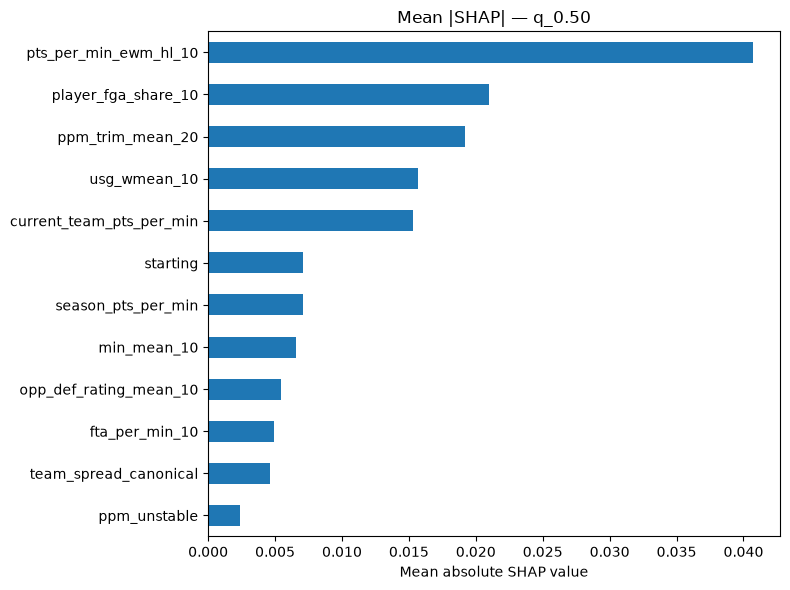

In [122]:
import shap

model = models_last["q_0.50"]
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_last)

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=PTS_FEATURES).sort_values(ascending=True)

ax = feat_imp.plot(kind="barh", figsize=(8, 6))
ax.set_title("Mean |SHAP| — q_0.50")
ax.set_xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()


In [123]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer
from scipy import stats as sp_stats

result = permutation_importance(
    models_last["q_0.50"],
    X_val_last,
    y_val_last,
    n_repeats=30,
    random_state=42,
    scoring=make_scorer(pinball_50),
)

pi_df = (
    pd.DataFrame({
        "feature": X_val_last.columns,
        "importance": result.importances_mean,
        "std": result.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
pi_df.index += 1
pi_df["importance"] = pi_df["importance"].round(5)
pi_df["std"] = pi_df["std"].round(5)
pi_df["p_value"] = sp_stats.ttest_1samp(result.importances, 0.0, axis=1).pvalue.round(4)
pi_df["significant"] = pi_df["p_value"] < 0.05

print("Permutation importance (val set) — higher = more important, significant = p<0.05")
print(pi_df.to_string())


Permutation importance (val set) — higher = more important, significant = p<0.05
                     feature  importance      std  p_value  significant
1      pts_per_min_ewm_hl_10     0.00394  0.00015      0.0         True
2        player_fga_share_10     0.00157  0.00008      0.0         True
3           ppm_trim_mean_20     0.00135  0.00009      0.0         True
4   current_team_pts_per_min     0.00083  0.00008      0.0         True
5               usg_wmean_10     0.00071  0.00006      0.0         True
6         season_pts_per_min     0.00038  0.00003      0.0         True
7                min_mean_10     0.00032  0.00004      0.0         True
8                   starting     0.00029  0.00003      0.0         True
9      team_spread_canonical     0.00020  0.00003      0.0         True
10            fta_per_min_10     0.00015  0.00003      0.0         True
11    opp_def_rating_mean_10     0.00013  0.00003      0.0         True
12              ppm_unstable     0.00011  0.00002      

In [124]:
train_mask_last = last_fold["train_mask"]
val_mask_last = last_fold["val_mask"]
X_tr_last = X.loc[train_mask_last]
X_va_last = X.loc[val_mask_last]
y_tr_last = ppm_df.loc[train_mask_last, TARGET_COL]
y_va_last = ppm_df.loc[val_mask_last, TARGET_COL]

ablation_df = run_feature_ablation(
    PTS_FEATURES, X_tr_last, y_tr_last, X_va_last, y_va_last,
    xgb_params=XGB_PARAMS,
)


Baseline pinball q50 (all features): 0.0956
                     feature  ablated_pinball  delta_pinball
1      team_spread_canonical           0.0958         0.0002
2      pts_per_min_ewm_hl_10           0.0957         0.0001
3   current_team_pts_per_min           0.0957         0.0001
4                   starting           0.0958         0.0001
5     opp_def_rating_mean_10           0.0957         0.0001
6                min_mean_10           0.0957         0.0001
7        player_fga_share_10           0.0957         0.0000
8           ppm_trim_mean_20           0.0956        -0.0000
9               usg_wmean_10           0.0956         0.0000
10        season_pts_per_min           0.0956         0.0000
11            fta_per_min_10           0.0956         0.0000
12              ppm_unstable           0.0957         0.0000


In [125]:
from scipy import stats

model = models_last["q_0.50"]
_shap_expl = shap.TreeExplainer(model, model_output="raw")
_shap_vals = _shap_expl(X_val_last)
_mean_abs_shap = np.abs(_shap_vals.values).mean(axis=0)

shap_table = pd.DataFrame({
    "feature": X_val_last.columns,
    "mean_abs_shap": _mean_abs_shap,
}).assign(shap_rank=lambda d: d["mean_abs_shap"].rank(method="min", ascending=False).astype(int))

perm_table = (
    pi_df.sort_values("importance", ascending=False)
    .reset_index(drop=True)
    .rename(columns={"importance": "perm_importance", "std": "perm_importance_std"})
)
perm_table["perm_rank"] = np.arange(1, len(perm_table) + 1)
perm_table = perm_table[["feature", "perm_rank", "perm_importance", "perm_importance_std"]]

perm_pv = pd.DataFrame({
    "feature": X_val_last.columns,
    "perm_pvalue": stats.ttest_1samp(result.importances, 0.0, axis=1, nan_policy="omit").pvalue,
})

abla = ablation_df[["feature", "delta_pinball"]].rename(columns={"delta_pinball": "ablation_delta"})

feature_audit = (
    pd.DataFrame({"feature": PTS_FEATURES})
    .merge(shap_table, on="feature", how="left")
    .merge(perm_table, on="feature", how="left")
    .merge(perm_pv, on="feature", how="left")
    .merge(abla, on="feature", how="left")
)

_ms = feature_audit["mean_abs_shap"].astype(float)
_mp = feature_audit["perm_importance"].astype(float)
_max_shap = _ms.fillna(0).max()
_max_perm = _mp.fillna(0).max()
feature_audit["shap_norm"] = np.where(_max_shap > 0, _ms.fillna(0) / _max_shap, 0.0)
feature_audit["perm_norm"] = np.where(_max_perm > 0, _mp.fillna(0) / _max_perm, 0.0)
feature_audit["consensus"] = (feature_audit["shap_norm"] + feature_audit["perm_norm"]) / 2
feature_audit = feature_audit.sort_values("consensus", ascending=False).reset_index(drop=True)
feature_audit.index += 1
feature_audit["keep"] = (feature_audit["perm_pvalue"] < 0.05) & (feature_audit["ablation_delta"] > 0)

print(feature_audit.to_string())


                     feature  mean_abs_shap  shap_rank  perm_rank  perm_importance  perm_importance_std   perm_pvalue  ablation_delta  shap_norm  perm_norm  consensus   keep
1      pts_per_min_ewm_hl_10       0.040693          1          1          0.00394              0.00015  2.021321e-42          0.0001   1.000000   1.000000   1.000000   True
2        player_fga_share_10       0.020947          2          2          0.00157              0.00008  4.474630e-39          0.0000   0.514759   0.398477   0.456618  False
3           ppm_trim_mean_20       0.019189          3          3          0.00135              0.00009  3.758017e-36         -0.0000   0.471548   0.342640   0.407094  False
4   current_team_pts_per_min       0.015300          5          4          0.00083              0.00008  7.722521e-32          0.0001   0.376001   0.210660   0.293331   True
5               usg_wmean_10       0.015678          4          5          0.00071              0.00006  1.566953e-32          0.0

### Slice Analysis


In [126]:
import importlib

import models.shared.artifacts as artifact_mod

importlib.reload(artifact_mod)
from models.shared.artifacts import monotonize_quantiles

dates = pd.to_datetime(ppm_holdout["game_date"])
y_all = np.asarray(y_ho, dtype=float)
raw_q = {key: np.asarray(pred, dtype=float) for key, pred in preds_ho.items()}
model = raw_q["q_0.50"]

def slice_score(name, mask, qmap):
    mask = np.asarray(mask, dtype=bool)
    n = int(mask.sum())
    if n == 0:
        return {"slice": name, "n": 0}
    y = y_all[mask]
    qmap = {key: values[mask] for key, values in qmap.items()}
    error = y - qmap["q_0.50"]
    return {
        "slice": name,
        "n": n,
        "mae": float(np.mean(np.abs(error))),
        "bias": float(np.mean(error)),
        "p_actual_le_q50": float(np.mean(y <= qmap["q_0.50"])),
        "cov_80": interval_coverage(y, qmap["q_0.10"], qmap["q_0.90"]),
        "mean_width_80": float(np.mean(qmap["q_0.90"] - qmap["q_0.10"])),
        "wis": float(np.mean(wis_values(y, qmap))),
    }

print("1. April is late regular season, not the postseason")
holdout_season = df.loc[df["season_year"].astype("string").eq(str(HOLDOUT_SEASON))]
print(holdout_season["season_type"].astype("string").value_counts(dropna=False).to_string())
print(
    f"Holdout dates {dates.min().date()} \u2192 {dates.max().date()}. "
    "The silver store only has regular_season gamelogs, so playoff games are not in this test."
)
blocks = {
    "October\u2013February": dates < "2026-03-01",
    "March 1\u201314": (dates >= "2026-03-01") & (dates < "2026-03-15"),
    "March 15\u201331": (dates >= "2026-03-15") & (dates < "2026-04-01"),
    "April regular season": dates >= "2026-04-01",
}
calendar = pd.DataFrame([slice_score(name, mask, raw_q) for name, mask in blocks.items()])
display(calendar.round(3))
print(
    "Limitation: April's higher MAE and lower 80% coverage is the last two weeks of the "
    "regular season. It is not a postseason effect, and the model has not been tested on playoff games."
)

print("\n2. Starter and bench mean bias versus median calibration")
starting = ppm_holdout["starting"].to_numpy()
role = pd.DataFrame([
    slice_score("Confirmed starter", starting == 1, raw_q),
    slice_score("Bench", starting == 0, raw_q),
])
display(role.round(3))
for _, row in role.iterrows():
    if row["n"] == 0:
        continue
    gap = row["p_actual_le_q50"] - 0.50
    if abs(gap) <= 0.02:
        reading = "q50 is near 50%, so the mean bias is skew around a calibrated median"
    elif gap > 0:
        reading = "q50 is too high: actuals fall under the median more often than 50%"
    else:
        reading = "q50 is too low: actuals fall under the median less often than 50%"
    print(
        f"  {row['slice']}: bias {row['bias']:+.3f} pts/min, "
        f"P(actual <= q50) {row['p_actual_le_q50']:.1%}. {reading}."
    )

print("\n3. Monotone rearrangement")
ordered_keys = sorted(raw_q, key=lambda key: float(str(key).split("_", 1)[1]))
grid = np.column_stack([raw_q[key] for key in ordered_keys])
crossed = np.any(np.diff(grid, axis=1) < 0, axis=1)
preds_ho_mono = monotonize_quantiles(raw_q)
mono_grid = np.column_stack([preds_ho_mono[key] for key in ordered_keys])
shift = pd.DataFrame([
    {
        "quantile": key,
        "mean_abs_shift": float(np.mean(np.abs(preds_ho_mono[key] - raw_q[key]))),
        "share_changed": float(np.mean(preds_ho_mono[key] != raw_q[key])),
    }
    for key in ordered_keys
])
print(
    f"Crossing before {crossed.mean():.2%} of rows; "
    f"after rearrangement {np.any(np.diff(mono_grid, axis=1) < 0, axis=1).mean():.2%}."
)
display(shift.round(4))
print("Simulate from preds_ho_mono. The saved trees stay raw; sort each row after predict.")

print("\n4. Cold-start and missing-baseline rows")
lag = ppm_holdout["pts_per_min_lag_1"].to_numpy(dtype=float)
season_avg = ppm_holdout["season_pts_per_min_mean"].to_numpy(dtype=float)
ewma = ppm_holdout["pts_per_min_ewm_hl_10"].to_numpy(dtype=float)
cold = ~np.isfinite(lag)
season_opener = np.isfinite(lag) & ~np.isfinite(season_avg)
missing_any = cold | season_opener | ~np.isfinite(ewma)
print(
    f"Missing any baseline: {int(missing_any.sum()):,} | "
    f"no prior game (pts_per_min_lag_1 missing): {int(cold.sum()):,} | "
    f"season opener with history: {int(season_opener.sum()):,}"
)

role_quantiles = {}
for role_value, role_name in ((1, "starter"), (0, "bench")):
    history = ppm_df.loc[ppm_df["starting"] == role_value, TARGET_COL].to_numpy(dtype=float)
    history = history[np.isfinite(history)]
    role_quantiles[role_name] = {
        key: float(np.quantile(history, float(str(key).split("_", 1)[1])))
        for key in ordered_keys
    }
fallback_q = {key: preds_ho_mono[key].copy() for key in ordered_keys}
for key in ordered_keys:
    fallback_q[key][cold & (starting == 1)] = role_quantiles["starter"][key]
    fallback_q[key][cold & (starting == 0)] = role_quantiles["bench"][key]

missing_table = pd.DataFrame([
    slice_score("Season opener, model", season_opener, raw_q),
    slice_score("No prior game, model", cold, raw_q),
    slice_score("No prior game, role fallback", cold, fallback_q),
    slice_score("Any missing baseline, model", missing_any, raw_q),
])
display(missing_table.round(3))
print(
    "Live fallback: if pts_per_min_lag_1 exists, predict with the quantile model and then "
    "sort that row into increasing quantile order, even when season_pts_per_min_mean is missing. "
    "If pts_per_min_lag_1 is missing, do not use the tree. Use the training-pool rate quantiles "
    "for the confirmed role (starter or bench). preds_ho_live applies that rule."
)
preds_ho_live = fallback_q


1. April is late regular season, not the postseason
season_type
Regular Season    26648
Holdout dates 2025-10-21 → 2026-04-12. The silver store only has regular_season gamelogs, so playoff games are not in this test.


,slice,n,mae,bias,p_actual_le_q50,cov_80,mean_width_80,wis
0,October–February,19417,0.189,0.025,0.498,0.805,0.587,0.128
1,March 1–14,2364,0.189,0.025,0.499,0.803,0.586,0.130
2,March 15–31,2806,0.194,0.033,0.485,0.797,0.589,0.131
3,April regular season,2061,0.204,0.058,0.444,0.785,0.602,0.138


Limitation: April's higher MAE and lower 80% coverage is the last two weeks of the regular season. It is not a postseason effect, and the model has not been tested on playoff games.

2. Starter and bench mean bias versus median calibration


,slice,n,mae,bias,p_actual_le_q50,cov_80,mean_width_80,wis
0,Confirmed starter,12300,0.158,0.015,0.492,0.788,0.496,0.109
1,Bench,14348,0.218,0.041,0.493,0.815,0.668,0.147


  Confirmed starter: bias +0.015 pts/min, P(actual <= q50) 49.2%. q50 is near 50%, so the mean bias is skew around a calibrated median.
  Bench: bias +0.041 pts/min, P(actual <= q50) 49.3%. q50 is near 50%, so the mean bias is skew around a calibrated median.

3. Monotone rearrangement
Crossing before 3.01% of rows; after rearrangement 0.00%.


,quantile,mean_abs_shift,share_changed
0,q_0.05,0.0000,0.0069
1,q_0.10,0.0001,0.0215
2,q_0.20,0.0001,0.0267
3,q_0.30,0.0001,0.0147
4,q_0.40,0.0000,0.0055
5,q_0.50,0.0000,0.0013
6,q_0.60,0.0000,0.0003
7,q_0.70,0.0000,0.0001
8,q_0.80,0.0000,0.0000
9,q_0.90,0.0000,0.0000


Simulate from preds_ho_mono. The saved trees stay raw; sort each row after predict.

4. Cold-start and missing-baseline rows
Missing any baseline: 582 | no prior game (pts_per_min_lag_1 missing): 104 | season opener with history: 478


,slice,n,mae,bias,p_actual_le_q50,cov_80,mean_width_80,wis
0,"Season opener, model",478,0.237,0.066,0.492,0.789,0.662,0.162
1,"No prior game, model",104,0.298,0.134,0.481,0.817,0.782,0.202
2,"No prior game, role fallback",104,0.310,0.013,0.615,0.817,0.727,0.210
3,"Any missing baseline, model",582,0.248,0.078,0.490,0.794,0.684,0.169


Live fallback: if pts_per_min_lag_1 exists, predict with the quantile model and then sort that row into increasing quantile order, even when season_pts_per_min_mean is missing. If pts_per_min_lag_1 is missing, do not use the tree. Use the training-pool rate quantiles for the confirmed role (starter or bench). preds_ho_live applies that rule.


### Error Analysis


In [127]:
# Holdout misses. Score, fouls, and plus/minus are post-game context.
# They explain a miss; they were not inputs to the model.
# pts is already on the holdout frame, so the context merge leaves it alone.
ctx = (
    df[[
        "game_id", "player_id", "team_abbreviation", "matchup", "wl",
        "pf", "pfd", "plus_minus", "team_pts", "opp_pts",
        "abs_spread",
    ]]
    .drop_duplicates(["game_id", "player_id"])
)
team_minutes = (
    df.groupby(["game_id", "team_abbreviation"], as_index=False)["minutes"]
    .sum()
    .rename(columns={"minutes": "team_minutes"})
)

miss = ppm_holdout.reset_index(drop=True).copy()
miss["q10"] = np.asarray(preds_ho["q_0.10"], dtype=float)
miss["q50"] = np.asarray(preds_ho["q_0.50"], dtype=float)
miss["q90"] = np.asarray(preds_ho["q_0.90"], dtype=float)
miss["error"] = miss[TARGET_COL] - miss["q50"]
miss["abs_error"] = miss["error"].abs()
miss = miss.merge(ctx, on=["game_id", "player_id"], how="left")
miss = miss.merge(team_minutes, on=["game_id", "team_abbreviation"], how="left")
miss["game_date"] = pd.to_datetime(miss["game_date"]).dt.date
miss["score"] = (
    miss["team_pts"].round().astype("Int64").astype("string")
    + "-"
    + miss["opp_pts"].round().astype("Int64").astype("string")
)
miss["margin"] = miss["team_pts"] - miss["opp_pts"]
miss["ot"] = miss["team_minutes"] >= 260
miss["band"] = (
    miss["q10"].round().astype("Int64").astype("string")
    + "–"
    + miss["q90"].round().astype("Int64").astype("string")
)

sat_early = miss["error"] <= -0.20
played_more = miss["error"] >= 0.20
blowout = miss["margin"].abs() >= 15
outside_80 = (miss[TARGET_COL] < miss["q10"]) | (miss[TARGET_COL] > miss["q90"])
miss["hint"] = np.select(
    [
        (miss["pf"] >= 6) & sat_early,
        (miss["pf"] >= 5) & sat_early,
        blowout & sat_early & (miss["starting"] == 1),
        blowout & played_more & (miss["starting"] == 0),
        miss["ot"] & played_more,
        (miss["starting"] == 0) & (miss["pts_per_min_lag_1"] >= 0.50) & (miss["error"] <= -0.25),
        (miss["starting"] == 1) & (miss["pts_per_min_lag_1"].fillna(0) < 0.35) & (miss["error"] >= 0.25),
        outside_80,
    ],
    [
        "fouled out",
        "foul trouble",
        "blowout rest",
        "garbage time",
        "overtime",
        "unexpected bench",
        "unexpected start",
        "outside 10–90",
    ],
    default="",
)

show = [
    "game_date", "player_name", "matchup", "score", "wl",
    TARGET_COL, "minutes", "pts", "q50", "error", "band", "pf", "pfd",
    "starting", "plus_minus", "margin",
    "pts_per_min_lag_1", "season_pts_per_min_mean", "abs_spread", "ot", "hint",
]
labels = {
    "game_date": "date",
    "player_name": "player",
    "matchup": "game",
    TARGET_COL: "actual_rate",
    "minutes": "minutes",
    "pts": "pts",
    "q50": "pred_q50",
    "error": "actual − q50",
    "band": "q10–q90",
    "pf": "fouls",
    "pfd": "fouls_drawn",
    "plus_minus": "+/-",
    "pts_per_min_lag_1": "last_game_rate",
    "season_pts_per_min_mean": "season_rate",
    "abs_spread": "pregame_|spread|",
}

def show_misses(frame, title):
    view = frame[show].rename(columns=labels).round(1)
    print(title)
    display(view)

way_off = miss["abs_error"] >= 0.25
print(
    f"{HOLDOUT_SEASON} holdout: {int(way_off.sum()):,} / {len(miss):,} rows "
    f"missed by 0.25+ points per minute ({way_off.mean():.1%}). "
    f"Median |error| {miss['abs_error'].median():.1f}."
)
print("actual − q50 > 0 means the points-per-minute rate was above the median prediction.")

show_misses(
    miss.nsmallest(20, "error"),
    "\nScored much less per minute than q50",
)
show_misses(
    miss.nlargest(20, "error"),
    "\nScored much more per minute than q50",
)

biggest = pd.concat(
    [miss.nsmallest(20, "error"), miss.nlargest(20, "error")],
    ignore_index=True,
)
print("\nHints on those 40 misses")
print(biggest["hint"].replace("", "unlabeled").value_counts().to_string())

rotation = miss["q50"] >= 0.45
off_players = (
    miss.loc[rotation & (miss["abs_error"] >= 0.25)]
    .sort_values("abs_error", ascending=False)
    .groupby(["game_id", "team_abbreviation"])
    .apply(
        lambda g: ", ".join(
            f"{row.player_name} ({row.minutes:.0f} min, {row.error:+.2f}, {int(row.pf)} PF)"
            for row in g.itertuples()
        ),
        include_groups=False,
    )
    .rename("players_off_by_0.25")
    .reset_index()
)
games = (
    miss.loc[rotation]
    .groupby(["game_id", "game_date", "team_abbreviation", "matchup", "score", "wl"], as_index=False)
    .agg(
        n_rotation=("player_id", "size"),
        n_off_025=("abs_error", lambda s: int((s >= 0.25).sum())),
        mean_abs_error=("abs_error", "mean"),
        margin=("margin", "mean"),
        ot=("ot", "max"),
    )
    .merge(off_players, on=["game_id", "team_abbreviation"], how="left")
    .sort_values(["n_off_025", "mean_abs_error"], ascending=False)
)
print("\nTeam-games where the most players (predicted q50 ≥ 0.45) missed by 0.25+ points per minute")
display(
    games.head(15)[
        [
            "game_date", "matchup", "score", "wl", "margin", "ot",
            "n_rotation", "n_off_025", "mean_abs_error", "players_off_by_0.25",
        ]
    ].rename(columns={"game_date": "date", "matchup": "game"}).round(1)
)


2025-26 holdout: 7,378 / 26,648 rows missed by 0.25+ points per minute (27.7%). Median |error| 0.2.
actual − q50 > 0 means the points-per-minute rate was above the median prediction.

Scored much less per minute than q50


,date,player,game,score,wl,actual_rate,minutes,pts,pred_q50,actual − q50,...,fouls,fouls_drawn,starting,+/-,margin,last_game_rate,season_rate,pregame_|spread|,ot,hint
2507,2025-11-05,Cam Thomas,BKN @ IND,112-103,W,0.0,5.6,0,0.8,-0.8,...,0,0,1,4,9,0.7,0.8,6.5,False,outside 10–90
25877,2026-04-08,Jalen Green,PHX vs. DAL,112-107,W,0.0,3.8,0,0.7,-0.7,...,0,0,1,-1,5,0.5,0.7,12.5,False,outside 10–90
18511,2026-02-22,Deni Avdija,POR @ PHX,92-77,W,0.0,1.0,0,0.7,-0.7,...,0,0,1,0,15,0.5,0.7,3.5,False,blowout rest
11266,2026-01-03,Alperen Sengun,HOU @ DAL,104-110,L,0.0,1.1,0,0.6,-0.6,...,0,0,1,0,-6,0.6,0.6,8.0,False,outside 10–90
6418,2025-11-30,Keyonte George,UTA vs. HOU,101-129,L,0.0,19.1,0,0.6,-0.6,...,1,2,1,-27,-28,0.9,0.7,11.5,False,blowout rest
10430,2025-12-29,Coby White,CHI vs. MIN,101-136,L,0.0,6.6,0,0.6,-0.6,...,0,0,1,1,-35,0.6,0.7,6.5,False,blowout rest
23248,2026-03-23,De'Anthony Melton,GSW @ DAL,137-131,W,0.0,22.5,0,0.6,-0.6,...,3,0,1,-1,6,0.9,0.6,2.5,True,outside 10–90
23753,2026-03-27,Donovan Mitchell,CLE vs. MIA,149-128,W,0.2,30.6,6,0.8,-0.6,...,2,3,1,14,21,0.8,0.8,5.5,False,blowout rest
11757,2026-01-06,Jordan Poole,NOP vs. LAL,103-111,L,0.0,18.3,0,0.6,-0.6,...,2,1,0,-8,-8,0.3,0.6,5.5,False,outside 10–90
21959,2026-03-16,Jaden Hardy,WAS vs. GSW,117-125,L,0.0,12.0,0,0.6,-0.6,...,2,0,0,4,-8,0.8,0.5,7.5,False,unexpected bench



Scored much more per minute than q50


,date,player,game,score,wl,actual_rate,minutes,pts,pred_q50,actual − q50,...,fouls,fouls_drawn,starting,+/-,margin,last_game_rate,season_rate,pregame_|spread|,ot,hint
5525,2025-11-23,Taylor Hendricks,UTA vs. LAL,106-108,L,4.9,0.6,3,0.3,4.6,...,0,0,0,0,-2,0.1,0.2,9.0,False,outside 10–90
1166,2025-10-27,Olivier-Maxence Prosper,MEM @ GSW,118-131,L,3.6,1.1,4,0.4,3.2,...,0,1,0,4,-13,0.0,0.4,8.0,False,outside 10–90
12766,2026-01-12,Bronny James,LAL @ SAC,112-124,L,3.2,1.9,6,0.1,3.1,...,0,0,0,4,-12,0.0,0.2,9.5,False,outside 10–90
24668,2026-04-01,Caleb Houstan,ATL @ ORL,130-101,W,3.2,2.8,9,0.2,3.0,...,2,0,0,6,29,0.9,0.3,2.5,False,garbage time
8777,2025-12-19,Keshad Johnson,MIA @ BOS,116-129,L,3.3,0.9,3,0.3,2.9,...,0,0,0,6,-13,0.3,0.3,7.5,False,outside 10–90
20292,2026-03-05,Micah Peavy,NOP @ SAC,133-123,W,3.1,0.6,2,0.2,2.9,...,0,1,0,0,10,0.0,0.3,7.0,False,outside 10–90
1824,2025-11-01,Johnny Juzang,MIN @ CHA,122-105,W,3.1,1.0,3,0.3,2.8,...,0,0,0,0,17,0.0,0.2,4.5,False,garbage time
21189,2026-03-11,Alijah Martin,TOR @ NOP,111-122,L,2.9,1.4,4,0.2,2.6,...,0,1,0,6,-11,0.6,0.3,1.0,False,outside 10–90
9239,2025-12-22,Kam Jones,IND @ BOS,95-103,L,2.9,0.7,2,0.2,2.6,...,0,0,0,2,-8,NaN,NaN,11.5,False,outside 10–90
22048,2026-03-16,Jordan Hawkins,NOP vs. DAL,129-111,W,2.9,1.8,5,0.2,2.6,...,0,1,0,3,18,0.0,0.3,8.5,False,garbage time



Hints on those 40 misses
hint
outside 10–90       21
garbage time         9
blowout rest         8
unexpected bench     2

Team-games where the most players (predicted q50 ≥ 0.45) missed by 0.25+ points per minute


,date,game,score,wl,margin,ot,n_rotation,n_off_025,mean_abs_error,players_off_by_0.25
2361,2026-04-12,MIA vs. ATL,143-117,W,26.0,False,5,5,0.4,"Jaime Jaquez Jr. (26 min, +0.49, 0 PF), Norman..."
1414,2026-02-01,DEN vs. OKC,111-121,L,-10.0,False,5,5,0.3,"Jonas Valanciunas (13 min, +0.45, 3 PF), Tim H..."
2208,2026-04-01,DEN @ UTA,130-117,W,13.0,False,6,5,0.3,"Jonas Valanciunas (13 min, +0.48, 2 PF), Aaron..."
1492,2026-02-07,UTA @ ORL,117-120,L,-3.0,False,6,5,0.3,"Brice Sensabaugh (23 min, -0.39, 0 PF), Jusuf ..."
2358,2026-04-12,DET @ IND,133-121,W,12.0,False,5,4,0.4,"Paul Reed (22 min, +0.66, 1 PF), Tobias Harris..."
721,2025-12-07,OKC @ UTA,131-101,W,30.0,False,4,4,0.4,"Chet Holmgren (23 min, +0.50, 2 PF), Aaron Wig..."
2238,2026-04-03,DAL vs. ORL,127-138,L,-11.0,False,6,4,0.4,"Cooper Flagg (34 min, +0.87, 3 PF), Khris Midd..."
1889,2026-03-11,DEN vs. HOU,129-93,W,36.0,False,5,4,0.4,"Aaron Gordon (22 min, -0.57, 0 PF), Jonas Vala..."
580,2025-11-24,SAC vs. MIN,117-112,W,5.0,True,4,4,0.4,"DeMar DeRozan (32 min, +0.50, 2 PF), Zach LaVi..."
307,2025-11-02,SAS @ PHX,118-130,L,-12.0,False,5,4,0.4,"Victor Wembanyama (34 min, -0.53, 4 PF), Dylan..."


### Save Exploratory Artifact


In [128]:
from datetime import datetime, timezone

def _iso_date(value):
    return pd.Timestamp(value).date().isoformat()

metadata = {
    "created_at": datetime.now(timezone.utc).isoformat(),
    "status": "exploratory",
    "model_name": "quantile_xgboost",
    "artifact_stem": ARTIFACT_STEM,
    "features": list(PTS_FEATURES),
    "label": TARGET_COL,
    "label_rule": "min(pts / minutes, 6.0), minutes > 0",
    "quantiles": list(QUANTILES),
    "point_forecast": 0.50,
    "interval": [0.10, 0.90],
    "params": {
        key: XGB_PARAMS[key]
        for key in (
            "objective",
            "n_estimators",
            "max_depth",
            "learning_rate",
            "subsample",
            "colsample_bytree",
            "reg_alpha",
            "reg_lambda",
            "min_child_weight",
            "early_stopping_rounds",
            "random_state",
        )
    },
    "seed": SEED,
    "train_range": [
        _iso_date(ppm_df["game_date"].min()),
        _iso_date(ppm_df["game_date"].max()),
    ],
    "holdout_season": HOLDOUT_SEASON,
    "holdout_range": [
        _iso_date(ppm_holdout["game_date"].min()),
        _iso_date(ppm_holdout["game_date"].max()),
    ],
    "primary_metric": "q50 pinball",
    "test_metrics": {
        "n": ho_metrics["n"],
        "pinball_q50": ho_metrics["pinball"],
        "coverage_80": ho_metrics.get("coverage_80pct"),
        "coverage_90": ho_metrics.get("coverage_90pct"),
        "walk_forward_pinball_q50": float(
            np.mean([row["pinball"] for row in wf_results])
        ),
    },
}
display(metadata)


{'created_at': '2026-10-05T16:46:31.119387+00:00',
 'status': 'exploratory',
 'model_name': 'quantile_xgboost',
 'artifact_stem': 'pts_nba_model',
 'features': ['pts_per_min_ewm_hl_10',
  'player_fga_share_10',
  'ppm_trim_mean_20',
  'current_team_pts_per_min',
  'usg_wmean_10',
  'season_pts_per_min',
  'starting',
  'fta_per_min_10',
  'ppm_unstable',
  'opp_def_rating_mean_10',
  'team_spread_canonical',
  'min_mean_10'],
 'label': 'pts_per_min',
 'label_rule': 'min(pts / minutes, 6.0), minutes > 0',
 'quantiles': [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95],
 'point_forecast': 0.5,
 'interval': [0.1, 0.9],
 'params': {'objective': 'reg:quantileerror',
  'n_estimators': 1695,
  'max_depth': 3,
  'learning_rate': 0.052852647946832816,
  'subsample': 0.5916232263322159,
  'colsample_bytree': 0.6284413523882679,
  'reg_alpha': 0.022871045941195746,
  'reg_lambda': 2.0960269065270034,
  'min_child_weight': 8,
  'early_stopping_rounds': 50,
  'random_state': 42},
 'seed': 4

In [129]:
import importlib
import models.shared.artifacts as artifact_mod

importlib.reload(artifact_mod)
save_model_bundle = artifact_mod.save_model_bundle
load_model_bundle = artifact_mod.load_model_bundle

save_path = save_model_bundle(
    models_ho,
    train_df=ppm_df,
    holdout_df=ppm_holdout,
    wf_results=wf_results,
    ho_metrics=ho_metrics,
    features=PTS_FEATURES,
    artifact_stem=ARTIFACT_STEM,
    metadata=metadata,
)

bundle = load_model_bundle(save_path)
models_loaded = bundle["quantile_models"]
feature_names = bundle["feature_names"]

assert list(X_ho.columns) == list(feature_names)
quantile_keys = sorted(
    models_loaded,
    key=lambda key: float(str(key).split("_", 1)[1]),
)
loaded_preds = pd.DataFrame({
    key: models_loaded[key].predict(X_ho) for key in quantile_keys
})
print("Saved quantiles:", ", ".join(loaded_preds.columns))
print(
    f"Loaded model pinball q50 (holdout): "
    f"{pinball_loss(y_ho, loaded_preds['q_0.50'], 0.50):.3f}"
)
print(
    f"Loaded model 80% coverage (holdout): "
    f"{interval_coverage(y_ho, loaded_preds['q_0.10'], loaded_preds['q_0.90']):.1%}"
)
print(f"Trained on data up to      : {bundle['train_end'].date()}")
print(f"Holdout through            : {bundle['val_end'].date()}")

loaded_preds.head(3)


Saved to /Users/alexgonzalez/Documents/nba_quant/models/saved_models/pts_nba_model_2026-04-12.joblib
Loaded /Users/alexgonzalez/Documents/nba_quant/models/saved_models/pts_nba_model_2026-04-12.joblib
Saved quantiles: q_0.05, q_0.10, q_0.20, q_0.30, q_0.40, q_0.50, q_0.60, q_0.70, q_0.80, q_0.90, q_0.95
Loaded model pinball q50 (holdout): 0.095
Loaded model 80% coverage (holdout): 80.2%
Trained on data up to      : 2025-04-13
Holdout through            : 2026-04-12


,q_0.05,q_0.10,q_0.20,q_0.30,q_0.40,q_0.50,q_0.60,q_0.70,q_0.80,q_0.90,q_0.95
0,0.277577,0.358281,0.443297,0.488164,0.538696,0.575678,0.619573,0.679318,0.754472,0.878069,0.975709
1,0.023969,0.080481,0.131999,0.165936,0.207035,0.250240,0.278847,0.350742,0.425391,0.542104,0.629023
2,-0.009917,-0.000976,0.075673,0.136151,0.220720,0.293309,0.370444,0.480529,0.585860,0.738826,0.884776


In [130]:
# Walk-forward and holdout predictions for scripts/build_oos_table.py

from models.shared.oos import holdout_prediction_frame, oof_prediction_frame

PREDICTIONS_PATH = ROOT / "data/oos/nba/rate_predictions.parquet"

wf_oof = wf["oof"]
folds_found = sorted(int(fold) for fold in wf_oof["fold_id"].unique())
assert folds_found == [1, 2, 3, 4, 5], f"expected 5 walk-forward folds, got {folds_found}"

walk_forward_rows = oof_prediction_frame(wf_oof, ppm_df).assign(
    starting=wf_oof["starting"].to_numpy(),
)
holdout_rows = holdout_prediction_frame(ppm_holdout, preds_ho).assign(
    starting=ppm_holdout[ROLE_COL].to_numpy(),
)
predictions = pd.concat([walk_forward_rows, holdout_rows], ignore_index=True)
PREDICTIONS_PATH.parent.mkdir(parents=True, exist_ok=True)
predictions.to_parquet(PREDICTIONS_PATH, index=False)

print(f"Wrote {len(predictions):,} rows to {PREDICTIONS_PATH.relative_to(ROOT)}")
predictions.groupby("window_id").agg(
    rows=("game_id", "size"),
    first=("game_date", "min"),
    last=("game_date", "max"),
)

Wrote 102,358 rows to data/oos/nba/rate_predictions.parquet


,rows,first,last
window_id,,,
-1,26648,2025-10-21,2026-04-12
1,14737,2022-11-03,2023-02-07
2,14919,2023-02-08,2023-12-05
3,15346,2023-12-06,2024-03-17
4,15441,2024-03-18,2025-01-02
5,15267,2025-01-03,2025-04-11


### Conclusion
**- Selected Model:** Quantile XGBoost (`reg:quantileerror`) at all 11 levels, 0.05 through 0.95. Params are the rate search from `pts_nba_model` (depth 3, 1,695 trees). Bundle stem `pts_nba_model`.

**- Primary test result:** Fill from the 2025-26 holdout cells after this notebook is run. Score q50 pinball, 80% and 90% coverage, WIS on the 11 knots, and adjacent-pair crossing. Compare XGBoost with the last-game, season-to-date, and EWMA rate baselines on the paired rows.

**- Operating point:** None for serving. The point forecast is q50. The uncertainty band is q10–q90. Sort the 11 knots before a probability is read.

**- Label:** `min(pts / minutes, 6.0)` on appearances. Zeros stay out. Training drops rates outside the train-pool Tukey fence. The holdout keeps them.
